In [4]:
import pandas as pd

df = pd.read_csv('data/raw/paysim.csv.csv')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (6362620, 11)

Data types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


In [3]:
print("Files in data/raw:", os.listdir('data/raw'))

Files in data/raw: ['paysim.csv.csv']


In [1]:
import pandas as pd

df = pd.read_csv('data/raw/paysim.csv.csv')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (6362620, 11)

Data types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


In [5]:
import matplotlib.pyplot as plt

fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)
print(f"\nFraud percentage: {fraud_counts[1] / len(df) * 100:.3f}%")
"
plt.figure(figsize=(6,4))
fraud_counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.show()"

SyntaxError: unterminated string literal (detected at line 6) (4247514547.py, line 6)

isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud percentage: 0.129


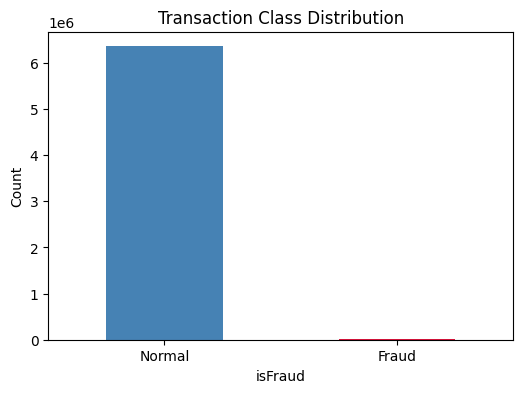

In [5]:
import matplotlib.pyplot as plt

fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)

fraud_pct = fraud_counts[1] / len(df) * 100
print('Fraud percentage:', round(fraud_pct, 3))

plt.figure(figsize=(6,4))
fraud_counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.show()

            count   sum
type                   
CASH_IN   1399284     0
CASH_OUT  2237500  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   532909  4097


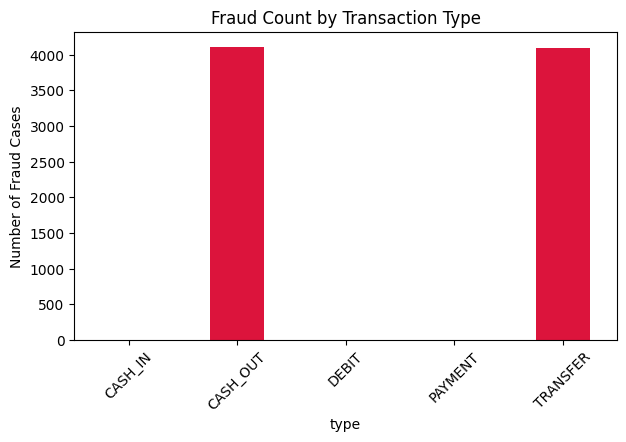

In [7]:
print(df.groupby('type')['isFraud'].agg(['count', 'sum']))

plt.figure(figsize=(7,4))
df.groupby('type')['isFraud'].sum().plot(kind='bar', color='crimson')
plt.title('Fraud Count by Transaction Type')
plt.ylabel('Number of Fraud Cases')
plt.xticks(rotation=45)
plt.show()

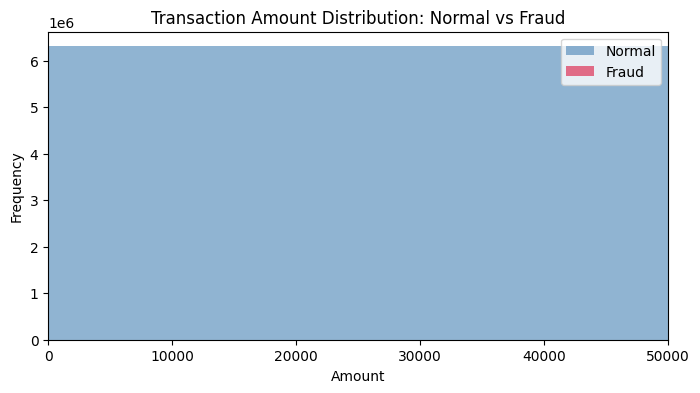

In [6]:
plt.figure(figsize=(8,4))
df[df['isFraud']==0]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Normal', color='steelblue')
df[df['isFraud']==1]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Fraud', color='crimson')
plt.legend()
plt.title('Transaction Amount Distribution: Normal vs Fraud')
plt.xlabel('Amount')
plt.xlim(0, 50000)
plt.show()

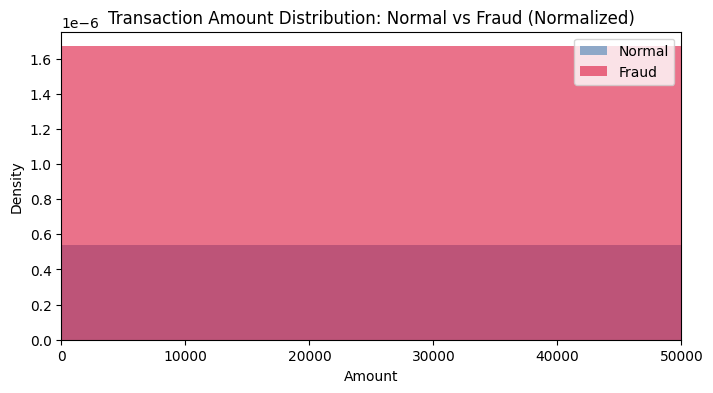

In [9]:
plt.figure(figsize=(8,4))
df[df['isFraud']==0]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
df[df['isFraud']==1]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Fraud', color='crimson', density=True)
plt.legend()
plt.title('Transaction Amount Distribution: Normal vs Fraud (Normalized)')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.xlim(0, 50000)
plt.show()


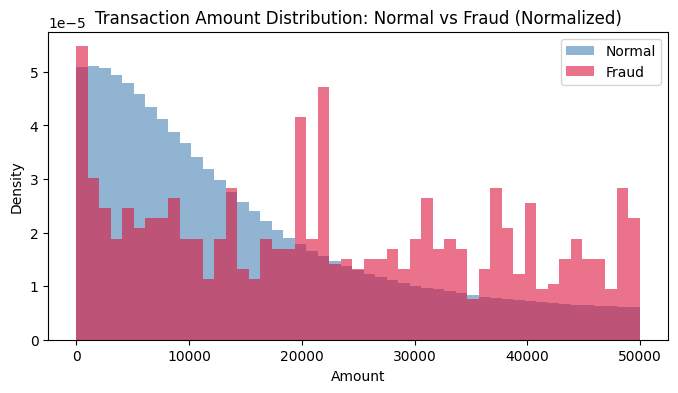

In [7]:
import numpy as np

bins = np.linspace(0, 50000, 50)

plt.figure(figsize=(8,4))
plt.hist(df[df['isFraud']==0]['amount'], bins=bins, alpha=0.6, label='Normal', color='steelblue', density=True)
plt.hist(df[df['isFraud']==1]['amount'], bins=bins, alpha=0.6, label='Fraud', color='crimson', density=True)
plt.legend()
plt.title('Transaction Amount Distribution: Normal vs Fraud (Normalized)')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.show()

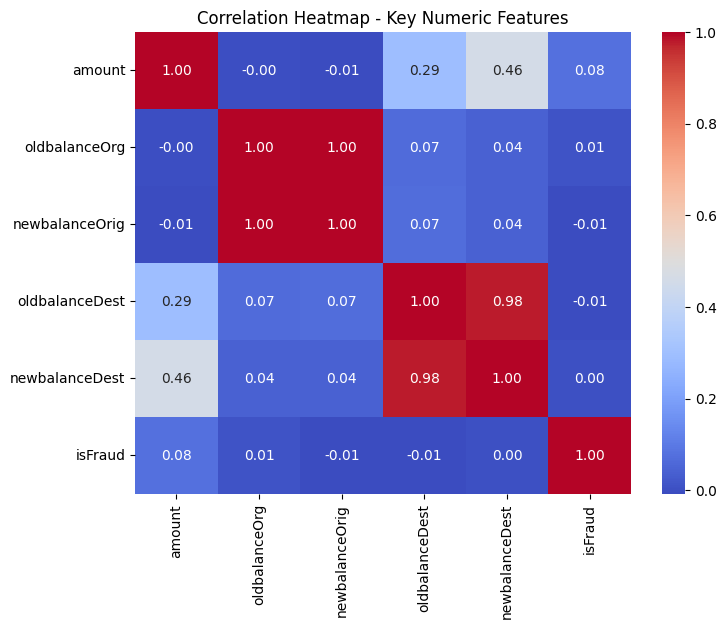

In [8]:
import seaborn as sns

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Key Numeric Features')
plt.show()

In [11]:
fraud_df = df[df['isFraud'] == 1]
normal_df = df[df['isFraud'] == 0]

print("Fraud where newbalanceOrig == 0:", round((fraud_df['newbalanceOrig'] == 0).mean() * 100, 2), "%")
print("Normal where newbalanceOrig == 0:", round((normal_df['newbalanceOrig'] == 0).mean() * 100, 2), "%")

print("\nFraud where oldbalanceDest == 0:", round((fraud_df['oldbalanceDest'] == 0).mean() * 100, 2), "%")
print("Normal where oldbalanceDest == 0:", round((normal_df['oldbalanceDest'] == 0).mean() * 100, 2), "%")

Fraud where newbalanceOrig == 0: 98.05 %
Normal where newbalanceOrig == 0: 56.68 %

Fraud where oldbalanceDest == 0: 65.15 %
Normal where oldbalanceDest == 0: 42.48 %


In [2]:
df['hour'] = df['step'] % 24

fraud_by_hour = df.groupby('hour')['isFraud'].agg(['count', 'sum'])
fraud_by_hour['fraud_rate'] = fraud_by_hour['sum'] / fraud_by_hour['count'] * 100

print(fraud_by_hour)

plt.figure(figsize=(10,4))
fraud_by_hour['fraud_rate'].plot(kind='bar', color='crimson')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.show()

       count  sum  fraud_rate
hour                         
0      71587  300    0.419071
1      27111  358    1.320497
2       9018  372    4.125083
3       2007  326   16.243149
4       1241  274   22.078969
5       1641  366   22.303473
6       3420  358   10.467836
7       8988  328    3.649310
8      26915  368    1.367267
9     283518  341    0.120275
10    425729  375    0.088084
11    445992  324    0.072647
12    483418  339    0.070126
13    468474  346    0.073857
14    439653  353    0.080291
15    416686  341    0.081836
16    441612  345    0.078123
17    439941  353    0.080238
18    580509  343    0.059086
19    647814  342    0.052793
20    553728  340    0.061402
21    247806  347    0.140029
22    194555  351    0.180412
23    141257  323    0.228661


NameError: name 'plt' is not defined

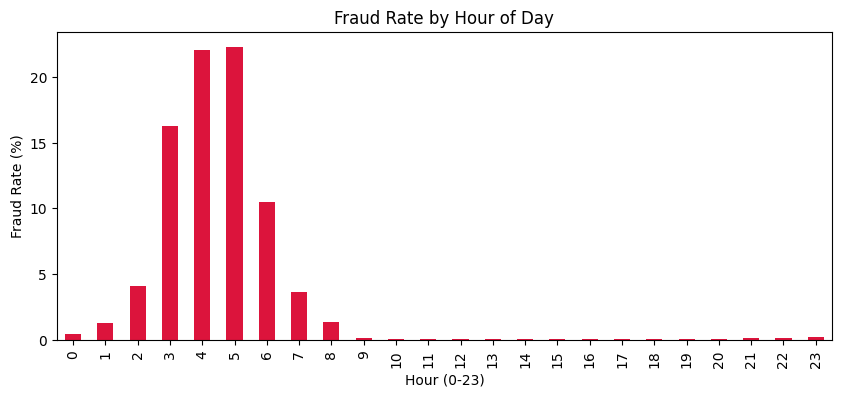

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
fraud_by_hour['fraud_rate'].plot(kind='bar', color='crimson')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.show()